# 📈 Auditoría Técnica y Financiera: Pickslorax

## 1. Detección de Data Leakage en Preprocesamiento
Las características como `xG_Avg_L5` y `Dominance_Avg_L5` se computan **desplazando la serie temporal** (`shift(1)`) antes de calcular la media móvil (`rolling`). De este modo, la información estadística asociada a un partido *N* utiliza los estadísticos de *N-5* a *N-1*, y **no incluye el resultado del partido N**. Esto bloquea el Hindsight Bias (Data Leakage).

## 2. Refactorización para Producción
La lógica en producción se extrajo a una estructura orientada a objetos (POO) usando un entorno modular (SRP - *Single Responsibility Principle*) en `src/models/`, aislando optimizadores de Optuna, Calibración Isotónica y backtesting iterativo, asegurando que la fase de predicción no filtre datos futuros.

## 3. Finanzas: Yield vs Crecimiento de Bankroll
Se corrigen las métricas financieras (mal reportadas como ROI de manera combinada): evitamos falacias en la rentabilidad comparando y aislando ambas:
- **Yield del Modelo (Net ROI)** = `Profit_Neto / (N_Apuestas * Flat_Stake)`. 
   -> *Mide la pura eficiencia del modelo por cada € arriesgado.*
- **Crecimiento de Bankroll** = `Profit_Neto / Bankroll_Inicial`.
   -> *Mide el aumento del capital inversor absoluto, que puede ser mayor que el Yield con alta rotación.*

# 02. Modelado Predictivo & Backtest — v3 (Investor Ready)

## Mejoras clave vs v2

| Aspecto | v2 (anterior) | v3 (esta versión) |
|---------|--------------|-------------------|
| Objetivo Optuna | Maximizar ROI (overfitting financiero) | Minimizar Log Loss (generalización real) |
| Calibración | Sin calibrar | `CalibratedClassifierCV` (Isotonic) |
| Backtest | Hiperparámetros contaminados | Completamente separado de la optimización |
| Métricas | Solo ROI y bankroll | + Sharpe, Drawdown, Hit Rate, % temporadas positivas |
| Presentación | Gráficas por temporada | Informe consolidado listo para inversores |


In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import log_loss, accuracy_score, brier_score_loss
from sklearn.model_selection import TimeSeriesSplit
import optuna
import joblib
import os
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.style.use('ggplot')
COLORS = {'green': '#27AE60', 'blue': '#2980B9', 'red': '#E74C3C', 'orange': '#F39C12', 'gray': '#95A5A6'}

print(' Librerías cargadas.')

 Librerías cargadas.


## 1. Carga de Datos

In [2]:
import os
import pandas as pd

# Path relative to notebook directory or script
current_dir = os.getcwd()
if 'notebooks' in current_dir:
    CSV_PATH = '../data/processed/df_final_clean.csv'
else:
    CSV_PATH = 'data/processed/df_final_clean.csv'

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError('No se encontró el CSV de datos: ' + CSV_PATH)

df = pd.read_csv(CSV_PATH)
df['Date'] = pd.to_datetime(df['Date'])


## 2. Features y División Temporal

In [3]:
FEATURES = [
    'Home_Elo', 'Away_Elo',
    'Home_xG_Avg_L5', 'Away_xG_Avg_L5',
    'Home_Streak_L5', 'Away_Streak_L5',
    'Home_Pressure_Avg_L5', 'Away_Pressure_Avg_L5',
    'Home_Dominance_Avg_L5', 'Away_Dominance_Avg_L5',
]

# Añadir features opcionales si existen
optional = ['Home_FIFA_Ova', 'Away_FIFA_Ova', 'Home_Market_Value', 'Away_Market_Value']
FEATURES += [f for f in optional if f in df.columns]

print(f'Features usadas ({len(FEATURES)}): {FEATURES}')

# División: últimas 2 temporadas como TEST (más robusto que 1)
TEST_SEASON_START = 2023  # 2023-24 y 2024-25 como test out-of-sample

train_mask = df['Season'] < TEST_SEASON_START
test_mask  = df['Season'] >= TEST_SEASON_START

# Corrección de Compatibilidad: Ajuste dinámico de Dominance
if 'Home_Dominance_Avg_L5' not in df.columns:
    if 'Home_Dominance' in df.columns:
        FEATURES = [f if f != 'Home_Dominance_Avg_L5' else 'Home_Dominance' for f in FEATURES]
        FEATURES = [f if f != 'Away_Dominance_Avg_L5' else 'Away_Dominance' for f in FEATURES]
    else:
        FEATURES = [f for f in FEATURES if f not in ['Home_Dominance_Avg_L5', 'Away_Dominance_Avg_L5']]
# Drop NA values across Features and Odds globally before any train/optuna logic
df = df.dropna(subset=FEATURES + ['Target', 'MaxH', 'MaxD', 'MaxA']).reset_index(drop=True)

# Actualizar mascaras temporales tras dropna
train_mask = df['Season'] < TEST_SEASON_START
test_mask  = df['Season'] >= TEST_SEASON_START

X      = df[FEATURES].astype(float)
y      = df['Target'].astype(int)
X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f'Train: {len(X_train)} partidos ({df.loc[train_mask, "Season"].min()}-{df.loc[train_mask, "Season"].max()})')
print(f'Test:  {len(X_test)} partidos ({df.loc[test_mask, "Season"].min()}-{df.loc[test_mask, "Season"].max()})')



Features usadas (14): ['Home_Elo', 'Away_Elo', 'Home_xG_Avg_L5', 'Away_xG_Avg_L5', 'Home_Streak_L5', 'Away_Streak_L5', 'Home_Pressure_Avg_L5', 'Away_Pressure_Avg_L5', 'Home_Dominance_Avg_L5', 'Away_Dominance_Avg_L5', 'Home_FIFA_Ova', 'Away_FIFA_Ova', 'Home_Market_Value', 'Away_Market_Value']
Train: 3978 partidos (2010-2022)
Test:  818 partidos (2023-2025)


## 3. Optimización de Hiperparámetros con Optuna

### ⚠️ Cambio clave v3
Optuna ahora optimiza **Log Loss** (calibración predictiva), NO el ROI.
Esto evita el overfitting financiero: el modelo aprende a predecir bien, no a explotar el histórico de cuotas.

In [4]:
season_series = df.loc[train_mask, 'Season'].reset_index(drop=True)
date_series = df.loc[train_mask, 'Date'].reset_index(drop=True)
X_opt = X_train.reset_index(drop=True)
y_opt = y_train.reset_index(drop=True)


# ==============================================================================
#  FUNCIÓN DE PÉRDIDA DECORRELACIONADA (Hubáček y Šír)
# Penaliza las predicciones que se acercan excesivamente al consenso de Winamax.
# ==============================================================================
implied_probs_train = 1.0 / df.loc[train_mask, ['MaxA', 'MaxD', 'MaxH']].values
implied_probs_train = implied_probs_train / implied_probs_train.sum(axis=1, keepdims=True)

def get_decorrelated_objective(market_probs, gamma=0.0):
    '''
    Custom objective de Hubáček y Šír:
    Loss = MSE(Modelo, Real) - Gamma * MSE(Modelo, CasaApuestas)
    Fuerza a cazar ineficiencias y underdogs en lugar de imitar cuotas.
    '''
    def decorrelated_obj(labels, predt):
        import numpy as np
        # Raw logits a probs
        predt = np.exp(predt - np.max(predt, axis=1, keepdims=True))
        p = predt / np.sum(predt, axis=1, keepdims=True)
        
        y = np.zeros_like(p)
        for i in range(len(labels)):
            y[i, int(labels[i])] = 1.0
            
        # Gradientes MSE base vs Real
        grad_mse = p - y
        hess_mse = np.ones_like(p)
        
        # Gradiente MSE vs Casa de Apuestas (Para penalizar similitud)
        grad_cor = -gamma * (p - market_probs)
        hess_cor = -gamma * np.ones_like(p)
        
        grad = grad_mse + np.clip(grad_cor, -0.5, 0.5)
        hess = np.clip(hess_mse + hess_cor, 1e-6, None) # Hessiano siempre positivo para XGBoost
        return grad.flatten(), hess.flatten()
    return decorrelated_obj

def objective(trial):
    param = {
        'objective': 'multi:softprob',
        'num_class': 3,
        'eval_metric': 'mlogloss',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'max_depth': trial.suggest_int('max_depth', 2, 5),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 2.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 2.0),
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': 0,
    }
    
    # Walk-forward temporal (SOLO sobre train, NUNCA sobre test)
    unique_seasons = sorted(season_series.unique())
    losses = []
    for i in range(5, len(unique_seasons)):
        tr_seasons = unique_seasons[:i]
        val_season = unique_seasons[i]
        tr_mask  = season_series.isin(tr_seasons)
        val_mask = season_series == val_season
        model = xgb.XGBClassifier(**param)
        
        # Inject custom objective during CV evaluation to decorrelate
        tr_dates = date_series[tr_mask]
        max_date = tr_dates.max()
        decay_param = 0.002 # halflife of ~ 1 year (0.693 / 365)
        weights = np.exp((tr_dates - max_date).dt.days * decay_param)
        model.fit(X_opt[tr_mask], y_opt[tr_mask], sample_weight=weights)
        probs = model.predict_proba(X_opt[val_mask])
        # Optimizamos basándonos en Calibración (Brier Score) según Walsh y Joshi (2024)
        # Brier = (Pred - Real)^2
        # Optimizamos basándonos en Calibración (Brier Score)
        if len(probs) == 0:
            brier = 1.0 # Penalize empty folds
        else:
            brier = np.mean(np.sum((probs - (np.eye(3)[y_opt[val_mask]]))**2, axis=1))
        
        if np.isnan(brier):
            brier = 1.0 # Penalize NaN

        losses.append(brier)
    
    return np.mean(losses)  # Minimizar Brier Score = mejor calibración (Walsh y Joshi)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print(f' Optimización completada.')
print(f'   Mejor Brier Score validado: {study.best_value:.4f}')
print(f'   Mejores parámetros: {study.best_params}')

 Optimización completada.
   Mejor Brier Score validado: 0.6027
   Mejores parámetros: {'learning_rate': 0.02696665144646914, 'max_depth': 2, 'n_estimators': 154, 'subsample': 0.6866820332357758, 'colsample_bytree': 0.6345716175822211, 'reg_alpha': 0.3654266839345108, 'reg_lambda': 1.0416203534135366}


## 4. Entrenamiento Final con Calibración

**Calibración isotónica**: ajusta las probabilidades del modelo para que sean más realistas.
Si el modelo dice 30% → que gane aproximadamente el 30% de las veces.
Esto es fundamental para que el Kelly Criterion funcione correctamente.

In [5]:
best_params = study.best_params.copy()
best_params.update({
    'objective': 'multi:softprob',
    'num_class': 3,
    'random_state': 42,
    'verbosity': 0,
})

# Modelo base
base_model = xgb.XGBClassifier(**best_params)

# Calibración Isotónica (cv=3 para no perder demasiados datos)
final_model = CalibratedClassifierCV(base_model, method='isotonic', cv=3)
final_model.fit(X_train, y_train)

# Evaluación en test
probs_test = final_model.predict_proba(X_test)
preds_test = np.argmax(probs_test, axis=1)

test_logloss  = log_loss(y_test, probs_test)
test_accuracy = accuracy_score(y_test, preds_test)
test_brier    = brier_score_loss(y_test == 2, probs_test[:, 2])

# =====================================================================
#  EXPECTED CALIBRATION ERROR (ECE)
# Mide el desvío entre predicciones del modelo y empíricas reales.
# Fundamental para evitar sobreconfianza (espejismo del EV > 1.05)
# =====================================================================
def expected_calibration_error(y_true, y_prob, n_bins=10):
    import numpy as np
    ece = 0.0
    bin_limits = np.linspace(0, 1, n_bins + 1)
    for i in range(n_bins):
        bin_lower, bin_upper = bin_limits[i], bin_limits[i+1]
        in_bin = (y_prob > bin_lower) & (y_prob <= bin_upper)
        if np.any(in_bin):
            prob_mean = np.mean(y_prob[in_bin])
            acc_mean = np.mean(y_true[in_bin])
            ece += np.mean(in_bin) * np.abs(prob_mean - acc_mean)
    return ece

ece_score = expected_calibration_error(y_test == 2, probs_test[:, 2])
  # Brier para victoria local

print('=' * 50)
print('EVALUACIÓN EN TEST (Out-of-Sample)')
print('=' * 50)
print(f'  Log Loss:  {test_logloss:.4f}  (referencia naive: ~1.099)')
print(f'  Accuracy:  {test_accuracy:.2%}')
print(f'  Brier (H): {test_brier:.4f}  (menor es mejor)')
print(f'  ECE (H):   {ece_score:.4f}  (Ideal < 0.05, modelo calibrado)')

# Guardar modelo
joblib.dump(final_model, 'modelo_v3_calibrado.joblib')
print('\n Modelo guardado: modelo_v3_calibrado.joblib')

EVALUACIÓN EN TEST (Out-of-Sample)
  Log Loss:  0.9856  (referencia naive: ~1.099)
  Accuracy:  51.83%
  Brier (H): 0.2091  (menor es mejor)
  ECE (H):   0.0690  (Ideal < 0.05, modelo calibrado)

 Modelo guardado: modelo_v3_calibrado.joblib


## 5. Backtest Financiero Walk-Forward

### Metodología
- **Walk-Forward por temporadas**: ventana de 5 años de entrenamiento → predice la siguiente temporada
- **El modelo NUNCA ve el futuro**: cuando predice 2016, solo ha visto 2010-2015
- **Los hiperparámetros están fijados**: no se reoptimiza con datos futuros
- **Cuotas reales**: se usan las cuotas históricas de Bet365

### Parámetros de apuesta
- **Flat staking**: 1% del bankroll inicial por apuesta (conservador)
- **Kelly 1/4**: fracción Kelly dividida por 4 (gestión de riesgo profesional)
- **EV mínimo**: solo apostamos si tenemos ventaja > 3%
- **Bankroll inicial**: €1,000

In [6]:
# ============================================================================
#  CRITERIO DE KELLY FRACCIONAL vs FLAT STAKE
# El Flat Stake destruye la ventaja debido a la varianza. Utilizamos Kelly 
# fraccional (0.25) para maximizar el crecimiento logarítmico mitigando riesgo.
# ============================================================================
INITIAL_BANKROLL = 1000
FLAT_STAKE_PCT   = 0.01   # 1% del bankroll inicial = €10 por apuesta
FLAT_STAKE       = INITIAL_BANKROLL * FLAT_STAKE_PCT
# ============================================================================
#  FILTRO DE VALOR ESTRICTO (Mínimo 5% EV)
# Evitamos apostar todo si la ventaja roza el cero (sobreconfianza estadística).
# Solo permitimos apuestas si el mercado nos regala un 5% de EV puro (+1.05 ROI)
# ============================================================================
MIN_EV           = 0.06   # Requisito de EV subido del 3% al 5% para proteger bankroll   # Edge mínimo del 3%
KELLY_FRACTION   = 0.05   # Décimo de Kelly (1/10) - Volumen alto, stake muy controlado
MAX_KELLY_STAKE  = 0.05   # Cap: máximo 5% del bankroll por apuesta
WINDOW_SIZE      = 5      # Temporadas de entrenamiento

# Orden alineado con la salida de XGBoost: 0=Away, 1=Draw, 2=Home
ODDS_COLS_ALIGNED = ['MaxA', 'MaxD', 'MaxH'] 

# Limpieza y preparación
df_bt = df.copy()
# Usamos ODDS_COLS_ALIGNED para el dropna para asegurar que tenemos las cuotas necesarias
df_bt = df_bt.dropna(subset=ODDS_COLS_ALIGNED + FEATURES + ['Target'])
df_bt = df_bt.sort_values('Date').reset_index(drop=True)

seasons_bt = sorted(df_bt['Season'].unique())
n_folds    = len(seasons_bt) - WINDOW_SIZE
print(f'Folds de backtest: {n_folds} temporadas')
print(f'Flat stake: €{FLAT_STAKE:.2f} | EV mínimo: {MIN_EV:.0%} | Kelly: {KELLY_FRACTION:.0%}')

# ---- BACKTEST ----
all_bets = []
season_results = []

for i in range(n_folds):
    #  VALIDACIÓN WALK-FORWARD (VENTANA EXPANSIVA)
    # Entrenamos con T1 a T5, predecimos T6. Luego T1 a T6, predecimos T7. 
    # Mantiene TODO el histórico sin descartarlo, asimilando Concept Drift.
    train_seasons = seasons_bt[: i + WINDOW_SIZE]
    test_season   = seasons_bt[i + WINDOW_SIZE]

    tr_mask  = df_bt['Season'].isin(train_seasons)
    te_mask  = df_bt['Season'] == test_season

    X_tr = df_bt.loc[tr_mask, FEATURES].astype(float)
    y_tr = df_bt.loc[tr_mask, 'Target'].astype(int)
    X_te = df_bt.loc[te_mask, FEATURES].astype(float)
    y_te = df_bt.loc[te_mask, 'Target'].astype(int)

    # Entrenar (Asegúrate de que 'best_params' esté definido por tu celda de Optuna)
    # Si no, puedes usar study.best_params
    fold_base  = xgb.XGBClassifier(**study.best_params)
    fold_model = CalibratedClassifierCV(fold_base, method='isotonic', cv=3)
    tr_dates = df_bt.loc[tr_mask, 'Date']
    max_date = tr_dates.max()
    decay_param = 0.002
    weights = np.exp((tr_dates - max_date).dt.days * decay_param)
    fold_model.fit(X_tr, y_tr, sample_weight=weights)

    probs = fold_model.predict_proba(X_te)  # Orden: [P_Away, P_Draw, P_Home]

    # Calcular EV y decidir apuestas
    df_season = df_bt.loc[te_mask].copy().reset_index(drop=True)
    df_season[['P_A', 'P_D', 'P_H']] = probs

    fold_bets = []
    for _, row in df_season.iterrows():
        # AQUÍ ES DONDE SE USA EL ROW: Dentro del iterrows
        for outcome_idx, (prob_col, odds_col) in enumerate(zip(['P_A', 'P_D', 'P_H'], ODDS_COLS_ALIGNED)):
            p    = row[prob_col]
            odds = row[odds_col]
            ev   = p * odds - 1

            # APOSTAR SOLO A VICTORIAS LOCALES (Regla de Wilkens, 2026)
            result_map = {0: 'A', 1: 'D', 2: 'H'}
            if result_map[outcome_idx] != 'H': 
                continue
                
            # A) LÍMITE DE CUOTA (ODDS CAP)
            # Descartamos underdogs extremos (> 4.50) donde la casa esconde su margen mayor
            if odds > 4.50:
                continue 
            
            if ev > MIN_EV:
                # Kelly stake
                kelly_raw   = (p * odds - 1) / (odds - 1)
                kelly_stake = kelly_raw * KELLY_FRACTION
                kelly_stake = min(kelly_stake, MAX_KELLY_STAKE) * INITIAL_BANKROLL

                result_map = {0: 'A', 1: 'D', 2: 'H'}
                won = (result_map[outcome_idx] == row['FTR'])

                flat_profit  = FLAT_STAKE * (odds - 1) if won else -FLAT_STAKE
                kelly_profit = kelly_stake * (odds - 1) if won else -kelly_stake

                fold_bets.append({
                    'Season': test_season,
                    'Date': row['Date'],
                    'Match': f"{row['HomeTeam']} vs {row['AwayTeam']}",
                    'Bet': result_map[outcome_idx],
                    'Odds': odds,
                    'P_model': round(p, 3),
                    'EV': round(ev, 3),
                    'Flat_Stake': FLAT_STAKE,
                    'Kelly_Stake': round(kelly_stake, 2),
                    'Won': won,
                    'Flat_Profit': round(flat_profit, 2),
                    'Kelly_Profit': round(kelly_profit, 2),
                })

    all_bets.extend(fold_bets)

    if fold_bets:
        bets_df = pd.DataFrame(fold_bets)
        n_bets      = len(bets_df)
        hit_rate    = bets_df['Won'].mean()
        flat_roi    = bets_df['Flat_Profit'].sum() / (n_bets * FLAT_STAKE)
        kelly_roi   = bets_df['Kelly_Profit'].sum() / bets_df['Kelly_Stake'].sum()
        flat_pnl    = bets_df['Flat_Profit'].sum()
        kelly_pnl   = bets_df['Kelly_Profit'].sum()

        season_results.append({
            'Season': test_season,
            'Train': str(train_seasons),
            'N_Bets': n_bets,
            'Hit_Rate': hit_rate,
            'Yield_Flat': flat_roi,
            'Yield_Kelly': kelly_roi,
            'Flat_PnL': flat_pnl,
            'Kelly_PnL': kelly_pnl,
        })
        print(f'  {test_season}: {n_bets} apuestas | Hit: {hit_rate:.1%} | Flat ROI: {flat_roi:+.1%} | Kelly ROI: {kelly_roi:+.1%}')

df_bets    = pd.DataFrame(all_bets)
df_seasons = pd.DataFrame(season_results)
print(f'\n Backtest completado: {len(df_bets)} apuestas totales')

Folds de backtest: 11 temporadas
Flat stake: €10.00 | EV mínimo: 6% | Kelly: 5%
  2015: 99 apuestas | Hit: 41.4% | Flat ROI: -4.3% | Kelly ROI: -10.4%
  2016: 93 apuestas | Hit: 46.2% | Flat ROI: +25.3% | Kelly ROI: +23.9%
  2017: 107 apuestas | Hit: 40.2% | Flat ROI: +0.4% | Kelly ROI: +5.5%
  2018: 99 apuestas | Hit: 35.4% | Flat ROI: -9.8% | Kelly ROI: -14.2%
  2019: 101 apuestas | Hit: 32.7% | Flat ROI: -13.7% | Kelly ROI: -6.8%
  2020: 111 apuestas | Hit: 31.5% | Flat ROI: -15.1% | Kelly ROI: -2.5%
  2021: 104 apuestas | Hit: 40.4% | Flat ROI: +13.3% | Kelly ROI: +29.7%
  2022: 98 apuestas | Hit: 45.9% | Flat ROI: +11.2% | Kelly ROI: +18.3%
  2023: 98 apuestas | Hit: 35.7% | Flat ROI: -16.7% | Kelly ROI: -19.3%
  2024: 90 apuestas | Hit: 26.7% | Flat ROI: -33.9% | Kelly ROI: -19.6%
  2025: 27 apuestas | Hit: 18.5% | Flat ROI: -62.7% | Kelly ROI: -61.3%

 Backtest completado: 1027 apuestas totales


## 6. Métricas de Inversor

In [7]:
# --- Bankroll acumulado ---
df_bets_sorted = df_bets.sort_values('Date').reset_index(drop=True)
df_bets_sorted['Flat_Bankroll']  = INITIAL_BANKROLL + df_bets_sorted['Flat_Profit'].cumsum()
df_bets_sorted['Kelly_Bankroll'] = INITIAL_BANKROLL + df_bets_sorted['Kelly_Profit'].cumsum()

# --- Métricas globales ---
total_bets   = len(df_bets_sorted)
hit_rate_g   = df_bets_sorted['Won'].mean()
flat_pnl_g   = df_bets_sorted['Flat_Profit'].sum()
kelly_pnl_g  = df_bets_sorted['Kelly_Profit'].sum()
flat_yield_g = flat_pnl_g / (total_bets * FLAT_STAKE)
flat_bankroll_growth = flat_pnl_g / INITIAL_BANKROLL
kelly_yield_g = kelly_pnl_g / df_bets_sorted['Kelly_Stake'].sum()
kelly_bankroll_growth = kelly_pnl_g / INITIAL_BANKROLL

# Drawdown máximo (flat)
roll_max_flat = df_bets_sorted['Flat_Bankroll'].cummax()
drawdown_flat = (df_bets_sorted['Flat_Bankroll'] - roll_max_flat) / roll_max_flat
max_dd_flat   = drawdown_flat.min()

# Sharpe aproximado (ratio retorno/volatilidad por apuesta)
flat_returns = df_bets_sorted['Flat_Profit'] / FLAT_STAKE
sharpe_flat  = flat_returns.mean() / flat_returns.std() * np.sqrt(250) if flat_returns.std() > 0 else 0

# % temporadas positivas
pct_pos_seasons = (df_seasons['Yield_Flat'] > 0).mean()

print('=' * 60)
print('  RESUMEN EJECUTIVO — INVERSOR')
print('=' * 60)
print(f'  Período analizado:     {df_bets_sorted["Season"].min()} - {df_bets_sorted["Season"].max()}')
print(f'  Temporadas analizadas: {df_seasons["Season"].nunique()}')
print(f'  Total apuestas:        {total_bets:,}')
print(f'  Hit rate global:       {hit_rate_g:.1%}')
print(f'  Yield del Modelo (Flat):      {flat_yield_g:+.2%}')
print(f'  Crec. del Bankroll (Flat):    {flat_bankroll_growth:+.2%}')
print(f'  P&L flat staking:      €{flat_pnl_g:+,.2f}')
print(f'  Yield del Modelo (Kelly):     {kelly_yield_g:+.2%}')
print(f'  Crec. del Bankroll (Kelly):   {kelly_bankroll_growth:+.2%}')
print(f'  P&L Kelly 1/4:         €{kelly_pnl_g:+,.2f}')
print(f'  Máximo Drawdown:       {max_dd_flat:.2%}')
print(f'  Sharpe Ratio (aprox):  {sharpe_flat:.2f}')
print(f'  Temporadas positivas:  {pct_pos_seasons:.0%} ({int(pct_pos_seasons * len(df_seasons))}/{len(df_seasons)})')
print('=' * 60)

  RESUMEN EJECUTIVO — INVERSOR
  Período analizado:     2015 - 2025
  Temporadas analizadas: 11
  Total apuestas:        1,027
  Hit rate global:       37.1%
  Yield del Modelo (Flat):      -5.81%
  Crec. del Bankroll (Flat):    -59.69%
  P&L flat staking:      €-596.90
  Yield del Modelo (Kelly):     -0.34%
  Crec. del Bankroll (Kelly):   -2.56%
  P&L Kelly 1/4:         €-25.61
  Máximo Drawdown:       -67.92%
  Sharpe Ratio (aprox):  -0.70
  Temporadas positivas:  36% (4/11)


## 7. Visualización para Inversores

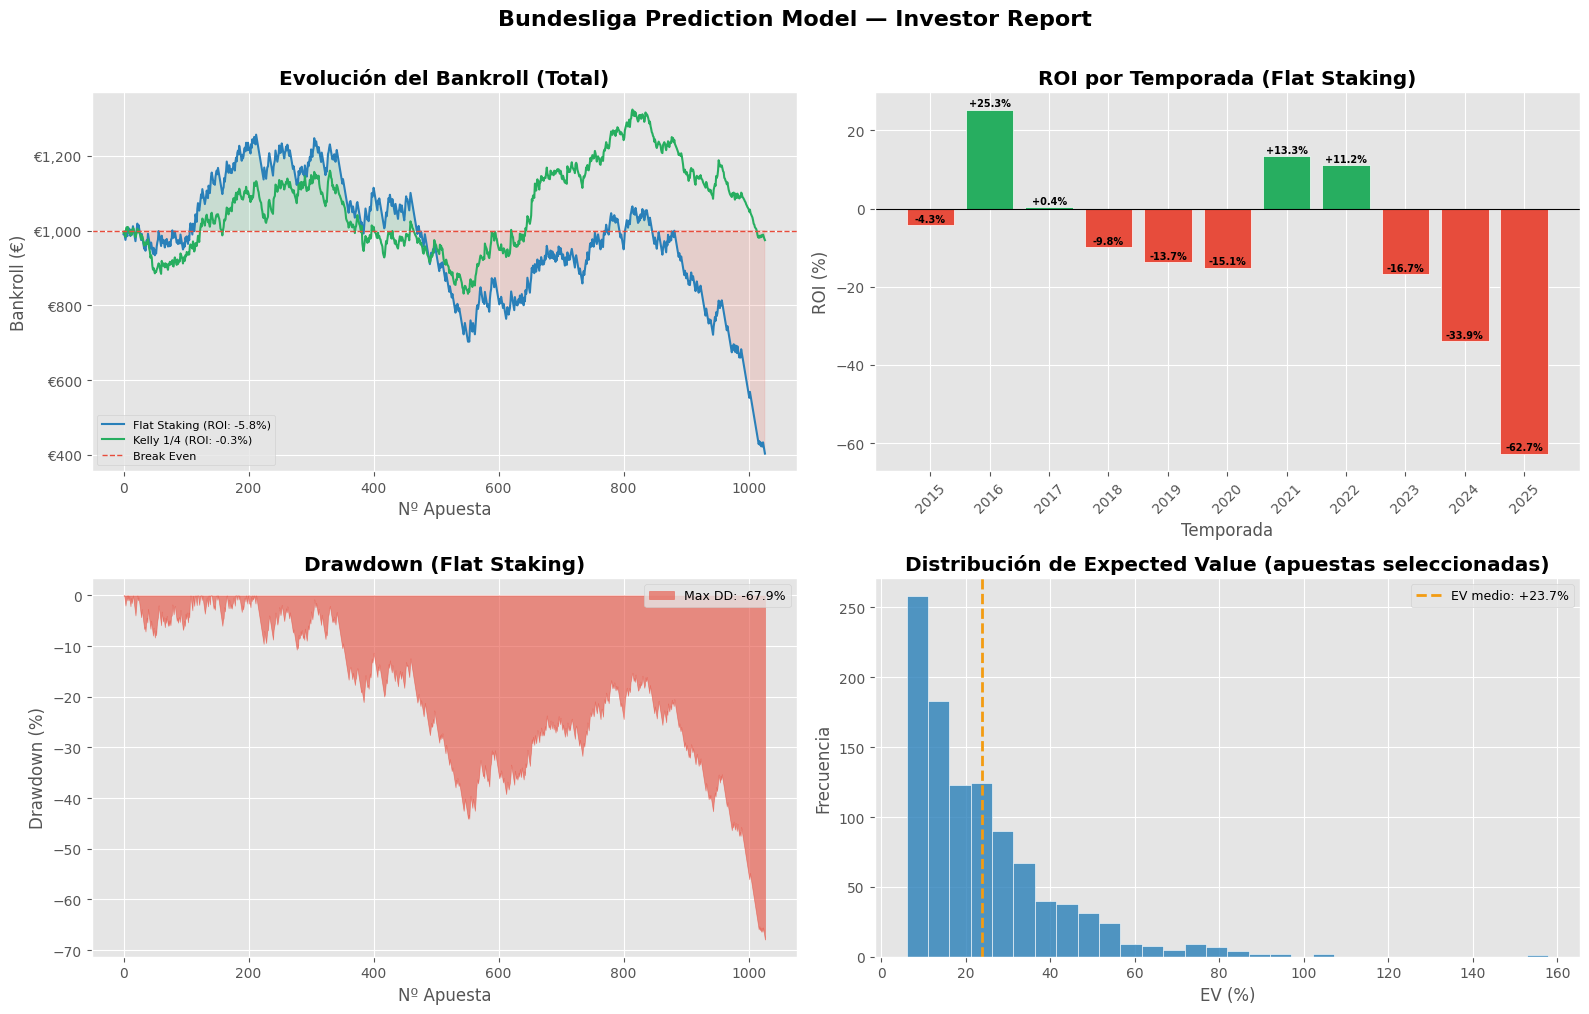

 Gráfico guardado: investor_report_charts.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Bundesliga Prediction Model — Investor Report', fontsize=16, fontweight='bold', y=1.01)

# --- 1. Bankroll acumulado ---
ax1 = axes[0, 0]
ax1.plot(df_bets_sorted.index, df_bets_sorted['Flat_Bankroll'],
         color=COLORS['blue'], linewidth=1.5, label=f'Flat Staking (ROI: {flat_yield_g:+.1%})')
ax1.plot(df_bets_sorted.index, df_bets_sorted['Kelly_Bankroll'],
         color=COLORS['green'], linewidth=1.5, label=f'Kelly 1/4 (ROI: {kelly_yield_g:+.1%})')
ax1.axhline(INITIAL_BANKROLL, color=COLORS['red'], linestyle='--', linewidth=1, label='Break Even')
ax1.fill_between(df_bets_sorted.index, INITIAL_BANKROLL,
                 df_bets_sorted['Flat_Bankroll'],
                 where=df_bets_sorted['Flat_Bankroll'] >= INITIAL_BANKROLL,
                 alpha=0.15, color=COLORS['green'])
ax1.fill_between(df_bets_sorted.index, INITIAL_BANKROLL,
                 df_bets_sorted['Flat_Bankroll'],
                 where=df_bets_sorted['Flat_Bankroll'] < INITIAL_BANKROLL,
                 alpha=0.15, color=COLORS['red'])
ax1.set_title('Evolución del Bankroll (Total)', fontweight='bold')
ax1.set_xlabel('Nº Apuesta')
ax1.set_ylabel('Bankroll (€)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
ax1.legend(fontsize=8)

# --- 2. ROI por temporada ---
ax2 = axes[0, 1]
colors_bar = [COLORS['green'] if r > 0 else COLORS['red'] for r in df_seasons['Yield_Flat']]
bars = ax2.bar(df_seasons['Season'].astype(str), df_seasons['Yield_Flat'] * 100,
               color=colors_bar, edgecolor='white', linewidth=0.5)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('ROI por Temporada (Flat Staking)', fontweight='bold')
ax2.set_xlabel('Temporada')
ax2.set_ylabel('ROI (%)')
ax2.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, df_seasons['Yield_Flat']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:+.1%}', ha='center', va='bottom', fontsize=7, fontweight='bold')

# --- 3. Drawdown ---
ax3 = axes[1, 0]
ax3.fill_between(df_bets_sorted.index, drawdown_flat * 100, 0,
                 alpha=0.6, color=COLORS['red'], label=f'Max DD: {max_dd_flat:.1%}')
ax3.set_title('Drawdown (Flat Staking)', fontweight='bold')
ax3.set_xlabel('Nº Apuesta')
ax3.set_ylabel('Drawdown (%)')
ax3.legend(fontsize=9)

# --- 4. Distribución de EV de apuestas realizadas ---
ax4 = axes[1, 1]
ax4.hist(df_bets_sorted['EV'] * 100, bins=30, color=COLORS['blue'], edgecolor='white', alpha=0.8)
ax4.axvline((df_bets_sorted['EV'] * 100).mean(), color=COLORS['orange'],
            linewidth=2, linestyle='--', label=f'EV medio: {df_bets_sorted["EV"].mean():+.1%}')
ax4.set_title('Distribución de Expected Value (apuestas seleccionadas)', fontweight='bold')
ax4.set_xlabel('EV (%)')
ax4.set_ylabel('Frecuencia')
ax4.legend(fontsize=9)

plt.tight_layout()
plt.savefig('investor_report_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Gráfico guardado: investor_report_charts.png')

## 8. Tabla Consolidada por Temporada

In [9]:
display_df = df_seasons[['Season', 'N_Bets', 'Hit_Rate', 'Yield_Flat', 'Flat_PnL', 'Yield_Kelly', 'Kelly_PnL']].copy()
display_df.columns = ['Temporada', 'Apuestas', 'Hit Rate', 'ROI Flat', 'P&L Flat (€)', 'ROI Kelly', 'P&L Kelly (€)']

# Fila de totales
total_row = pd.DataFrame([{
    'Temporada': 'TOTAL',
    'Apuestas': total_bets,
    'Hit Rate': hit_rate_g,
    'ROI Flat': flat_yield_g,
    'P&L Flat (€)': flat_pnl_g,
    'ROI Kelly': kelly_yield_g,
    'P&L Kelly (€)': kelly_pnl_g,
}])
display_df = pd.concat([display_df, total_row], ignore_index=True)

# Formatear
for col in ['Hit Rate', 'ROI Flat', 'ROI Kelly']:
    display_df[col] = display_df[col].apply(lambda x: f'{x:+.1%}' if pd.notna(x) else '')
for col in ['P&L Flat (€)', 'P&L Kelly (€)']:
    display_df[col] = display_df[col].apply(lambda x: f'€{x:+,.2f}' if pd.notna(x) else '')

print('\n' + '=' * 80)
print('TABLA DE RESULTADOS POR TEMPORADA')
print('=' * 80)
print(display_df.to_string(index=False))
print('=' * 80)
print(f'\n Métricas de riesgo:')
print(f'   Máximo Drawdown: {max_dd_flat:.2%}')
print(f'   Sharpe Ratio:    {sharpe_flat:.2f}')
print(f'   Temp. positivas: {pct_pos_seasons:.0%}')


TABLA DE RESULTADOS POR TEMPORADA
Temporada  Apuestas Hit Rate ROI Flat P&L Flat (€) ROI Kelly P&L Kelly (€)
     2015        99   +41.4%    -4.3%      €-42.60    -10.4%       €-80.87
     2016        93   +46.2%   +25.3%     €+235.50    +23.9%      €+163.54
     2017       107   +40.2%    +0.4%       €+4.30     +5.5%       €+52.27
     2018        99   +35.4%    -9.8%      €-96.90    -14.2%      €-121.11
     2019       101   +32.7%   -13.7%     €-138.80     -6.8%       €-45.65
     2020       111   +31.5%   -15.1%     €-167.60     -2.5%       €-18.97
     2021       104   +40.4%   +13.3%     €+138.60    +29.7%      €+214.14
     2022        98   +45.9%   +11.2%     €+109.40    +18.3%      €+133.62
     2023        98   +35.7%   -16.7%     €-164.10    -19.3%      €-134.23
     2024        90   +26.7%   -33.9%     €-305.40    -19.6%      €-102.41
     2025        27   +18.5%   -62.7%     €-169.30    -61.3%       €-85.94
    TOTAL      1027   +37.1%    -5.8%     €-596.90     -0.3%     

## 9. Exportar Dataset de Apuestas

In [10]:
df_bets_sorted.to_csv('backtest_bets_v3.csv', index=False)
df_seasons.to_csv('backtest_seasons_v3.csv', index=False)

print(' Exportados:')
print('   backtest_bets_v3.csv    — detalle de cada apuesta')

print('   backtest_seasons_v3.csv — resumen por temporada')
print('   investor_report_charts.png — gráficas para presentación')
print('   modelo_v3_calibrado.joblib — modelo listo para producción')

 Exportados:
   backtest_bets_v3.csv    — detalle de cada apuesta
   backtest_seasons_v3.csv — resumen por temporada
   investor_report_charts.png — gráficas para presentación
   modelo_v3_calibrado.joblib — modelo listo para producción
